Dataset Preview:
    Hours_Studied  Attendance  Assignment_Score  Midterm_Score  Final_Score
0              1          60                55             50           52
1              2          65                58             55           57
2              3          70                60             58           60
3              4          75                65             62           64
4              5          80                68             65           68

Dataset Shape: (20, 5)

After Encoding Columns:
 Index(['Hours_Studied', 'Attendance', 'Assignment_Score', 'Midterm_Score',
       'Final_Score'],
      dtype='object')

===== LINEAR REGRESSION RESULTS =====
MAE: 0.41749050153075906
MSE: 0.2612765457256682
RMSE: 0.5111521747245806
R2 Score: 0.9957516008825095


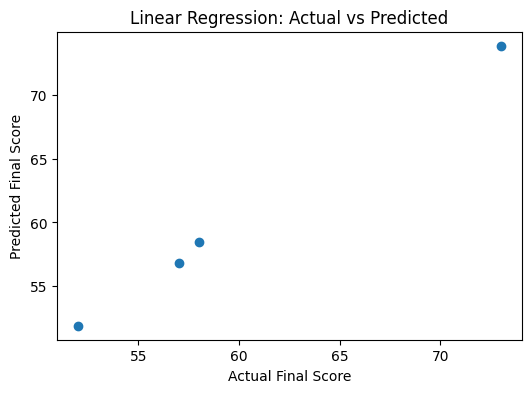


Pass/Fail Distribution:
 Pass
1    13
0     7
Name: count, dtype: int64

===== LOGISTIC REGRESSION RESULTS =====
Accuracy: 1.0
Confusion Matrix:
 [[3 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



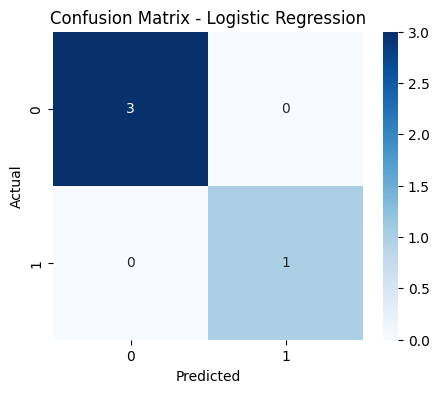

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



===== HYPERPARAMETER TUNING =====
Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 1.0


In [ ]:
# =====================================
# STEP 1: Import Required Libraries
# =====================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)

# =====================================
# STEP 2: Load Dataset
# =====================================
df = pd.read_csv("/content/student_performance.csv")
print("Dataset Preview:\n", df.head())
print("\nDataset Shape:", df.shape)

# =====================================
# STEP 3: Data Cleaning + Encoding
# =====================================
# Drop missing values
df = df.dropna()

# Convert categorical columns to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nAfter Encoding Columns:\n", df_encoded.columns)

# =====================================
# PART A: LINEAR REGRESSION
# Target: Final_Score (Continuous)
# =====================================
X_lr = df_encoded.drop(columns=["Final_Score"])
y_lr = df_encoded["Final_Score"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train_lr, y_train_lr)

y_pred_lr = lr.predict(X_test_lr)

print("\n===== LINEAR REGRESSION RESULTS =====")
print("MAE:", mean_absolute_error(y_test_lr, y_pred_lr))
print("MSE:", mean_squared_error(y_test_lr, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_lr, y_pred_lr)))
print("R2 Score:", r2_score(y_test_lr, y_pred_lr))

plt.figure(figsize=(6,4))
plt.scatter(y_test_lr, y_pred_lr)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# =====================================
# PART B: LOGISTIC REGRESSION
# Convert Final_Score → Pass / Fail
# Threshold = 65
# =====================================
df_encoded["Pass"] = df_encoded["Final_Score"].apply(lambda x: 1 if x >= 65 else 0)

print("\nPass/Fail Distribution:\n", df_encoded["Pass"].value_counts())

X_lg = df_encoded.drop(columns=["Final_Score", "Pass"])
y_lg = df_encoded["Pass"]

X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(
    X_lg, y_lg, test_size=0.2, random_state=42
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_lg, y_train_lg)

y_pred_log = log_reg.predict(X_test_lg)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print("Accuracy:", accuracy_score(y_test_lg, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_lg, y_pred_log))
print("Classification Report:\n", classification_report(y_test_lg, y_pred_log))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_lg, y_pred_log), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# =====================================
# PART C: HYPERPARAMETER TUNING
# Logistic Regression
# =====================================
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)

grid.fit(X_train_lg, y_train_lg)

print("\n===== HYPERPARAMETER TUNING =====")
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)
